# Reconstructing Optical Processes 

This code loads a trained neural network and external synthetic/experimental data to reconstruct specific processes. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from neuralnet import mse_cyclic_2, mse_cyclic_3,  mse_cyclic_4
from dataGenNew import generate_random_function, Ugen, full_measure, full_measure_reorder
import time
import math

# Some useful functions 

# Computes the fidelity between two unitaries (if unnormalized, you get back values > 1)
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

# Reconstructs unitary out of the matrices
def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

# Reconstructs the whole unitary pixelwise and computes the pixelwise fidelity. Returns the average fidelity matrix.
def compute_avg_fid(U_theo, U_exp, num_pix, isInverse = False):
    
    En_exp, nx_exp, ny_exp, nz_exp = U_exp[0,:,:], U_exp[1,:,:], U_exp[2,:,:], U_exp[3,:,:]
    
    if(isInverse):
        En_theo = U_theo[0,:,:]
        nx_theo = -U_theo[3,:,:]
        ny_theo = -U_theo[2,:,:]
        nz_theo = -U_theo[1,:,:]
    else:
        En_theo, nx_theo, ny_theo, nz_theo = U_theo[0,:,:], U_theo[1,:,:], U_theo[2,:,:], U_theo[3,:,:]
    
    Fvals=np.zeros([num_pix,num_pix])
    for i in range(num_pix):
        for j in range(num_pix):
            netU=op_par(En_exp[i,j],nx_exp[i,j],ny_exp[i,j],nz_exp[i,j])
            thU=op_par(En_theo[i,j], nx_theo[i,j], ny_theo[i,j], nz_theo[i,j])
            Fvals[i,j]=fidelity(netU,thU)
    
    return Fvals, np.mean(Fvals)


def get_unitary_params(En,theta,phi):
    En = En
    nx = np.sin(theta)*np.cos(phi)
    ny = np.sin(theta)*np.sin(phi)
    nz = np.cos(theta)
    return En, nx, ny, nz


Start by loading the trained model

In [108]:
mol_current_best = '64Net_BiggerTrain' # 50k dataset using old normalization
mol_biased_best = '64Net_withPlates' # 50k dataset using old normalization trained w/ 10% bias towards single- and two- waveplate processes. 

# New normalization

regular_model = '64Net_newNorm' # 100k, 64 x 64 resolution w/ latest normalization routine
biased_model = '64Net_wps_10percent' # this will be the above retrained w/ 10,000 waveplates

# Six Measurements

mol_sixMeasure = '64Net_sixMeasure'

loaded_model = tf.keras.models.load_model(mol_current_best, custom_objects={'math': math, 'mse_cyclic_2':mse_cyclic_2, 'mse_cyclic_4': mse_cyclic_4, 'mse_cyclic_3':mse_cyclic_3}, compile=True)

# Load up both synthetic AND experimental data at the same time

Select a process to run

In [254]:
# Select a process to run
process_num = 4

# Enable six measurments? 
sixMeasure = False

Load up the data

In [255]:
# This updates all directories to the one that we want
process_list = {1:"Tx(pi)", 2:"Ty(pi2)Tx(pi2)W", 3:"Tx(pi)WTx(pi2)WTx(pi2)", 4:"QPlate",  5:"T2y(1)T2x(1)WTy(pi2)Tx(pi2)W"}
process_unnamed = process_list[process_num]
process = "/" + process_unnamed

# Select a resolution 
num_pix = 64

# This holds our experimental data

if(sixMeasure):
    full_meas_exp = np.zeros((num_pix, num_pix, 6))
else:
    full_meas_exp = np.zeros((num_pix,num_pix, 5))

# Complete the synthetic and experimental directories 
synth_path = f"theoretical_data/{num_pix}"
synth_direc = synth_path + process
exp_path = "experimental_data"
exp_direc = exp_path + process

# For the synthetic data, we load up the theoretical unitary params
if (process == "/QPlate"):
    En_th_mat = np.loadtxt(synth_direc+'/en.txt') 
    theta_th_mat = np.loadtxt(synth_direc +'/theta.txt')
    phi_th_mat = np.loadtxt(synth_direc +'/phi.txt')
    
    # For the eventual purposes of plotting, recompute the cartesian unitary params
    nx_th_mat = np.sin(theta_th_mat)*np.cos(phi_th_mat)
    ny_th_mat = np.sin(theta_th_mat)*np.sin(phi_th_mat)
    nz_th_mat = np.cos(theta_th_mat)

else:
    En_th_mat = np.loadtxt(synth_direc+'/en.txt') 
    nx_th_mat = np.loadtxt(synth_direc+'/nx.txt') 
    ny_th_mat = np.loadtxt(synth_direc+'/ny.txt') 
    nz_th_mat = np.loadtxt(synth_direc+'/nz.txt') 
    
    # For the immediate purpose of allowing the neural network to do its thing, recompute the spherical unitary params
    theta_th_mat = np.arccos(nz_th_mat)
    phi_th_mat = np.arctan2(ny_th_mat, nx_th_mat)
    
    # For phi, wrap from [-pi, pi] to [0, 2pi]
    for i in range(num_pix):
        for j in range(num_pix):
            if (phi_th_mat[i,j]<0):
                phi_th_mat[i,j] += 2*np.pi

Some parameters for the measurement. Keep in mind that the synthetic predictions will be silghtly different (and, therefore, have silghtly different fidelities) because of the noise parameter, so keep that in mind!!

In [256]:
isReord = True
noise = 0.00
stateNoise = 0.00

Now, with that settled, let's compute the measurements

In [257]:
# For the synthetic reconstructions 
full_meas_synth = full_measure(En_th_mat,theta_th_mat,phi_th_mat,num_pix,noise,stateNoise, rotateBasis=isReord, sixMeasure = sixMeasure)

# For the experimental data, we load the images 
full_meas_exp[:,:,0] = np.loadtxt(exp_direc+f"/LL{num_pix}.txt")
if(isReord):
    full_meas_exp[:,:,1] = np.loadtxt(exp_direc+f"/HL{num_pix}.txt")
else:
    full_meas_exp[:,:,1] = np.loadtxt(exp_direc+f"/LH{num_pix}.txt")
full_meas_exp[:,:,2] = np.loadtxt(exp_direc+f"/LD{num_pix}.txt")
full_meas_exp[:,:,3] = np.loadtxt(exp_direc+f"/HH{num_pix}.txt")
full_meas_exp[:,:,4] = np.loadtxt(exp_direc+f"/HD{num_pix}.txt")
if (sixMeasure):
    full_meas_exp[:,:,5] =  np.loadtxt(exp_direc+f"/HL{num_pix}.txt")

# Swap things around (if applicable)
if (isReord):
    full_meas_synth = full_measure_reorder(full_meas_synth, num_pix)
    full_meas_exp = full_measure_reorder(full_meas_exp, num_pix)
    
# For tensorflow purposes, expand artifically by one dimension
full_meas_synth = tf.expand_dims(full_meas_synth, axis=0)
full_meas_exp = tf.expand_dims(full_meas_exp, axis=0)

PROMPT the network to make predictions

In [258]:
# synthetic predictions 
print('Predicting from synthetic measurments...')
synth_pred=loaded_model.predict(full_meas_synth)
print('Done!')
En_synth_pred, nx_synth_pred, ny_synth_pred, nz_synth_pred = get_unitary_params(synth_pred[0,:,:,0], synth_pred[0,:,:,1], synth_pred[0,:,:,2])

#experimental predictions
print('Predicting from experiments measurments...')
exp_pred=loaded_model.predict(full_meas_exp)
print('Done!')
En_exp_pred, nx_exp_pred, ny_exp_pred, nz_exp_pred = get_unitary_params(exp_pred[0,:,:,0], exp_pred[0,:,:,1], exp_pred[0,:,:,2])

Predicting from synthetic measurments...
1/1 [==============================] - 0s 395ms/step
Done!
Predicting from experiments measurments...
1/1 [==============================] - 0s 453ms/step
Done!


For the synthetic case, we compute the average fidelity

In [259]:
print("Compute average fidelity of process...")
Fvals, avg_fid =compute_avg_fid(np.array([En_th_mat, nx_th_mat, ny_th_mat, nz_th_mat]), np.array([En_synth_pred, nx_synth_pred, ny_synth_pred, nz_synth_pred]), num_pix, isInverse = isReord)
print(f"Done! The average fidelity is {avg_fid}")

Compute average fidelity of process...
Done! The average fidelity is 0.9370343737867324


Compute the polametric infidelity, $\Delta$

In [260]:
# determine the polametric measurements from network's prediction on the experimental data
meas_from_exp_pred = full_measure(En_exp_pred, exp_pred[0,:,:,1], exp_pred[0,:,:,2], num_pix, noise, stateNoise, rotateBasis=isReord, sixMeasure = sixMeasure)

# same thing but on synthetic data
meas_from_synth_pred = full_measure(En_synth_pred, synth_pred[0,:,:,1], synth_pred[0,:,:,2], num_pix, noise, stateNoise, rotateBasis=isReord, sixMeasure = sixMeasure)

# Compute the polametric infidelity, which is MSE
exp_pol_delta = np.square(np.subtract(full_meas_exp,meas_from_exp_pred)).mean()
synth_pol_delta = np.square(np.subtract(full_meas_synth,meas_from_synth_pred)).mean()

print(f"Experimental Delta: {exp_pol_delta}")
print(f"Synthetic Delta: {synth_pol_delta}")

Experimental Delta: 0.06575820051498615
Synthetic Delta: 0.10499400401725474


Make a subplot consisting of the theoretical, predicted, and experimental predictions

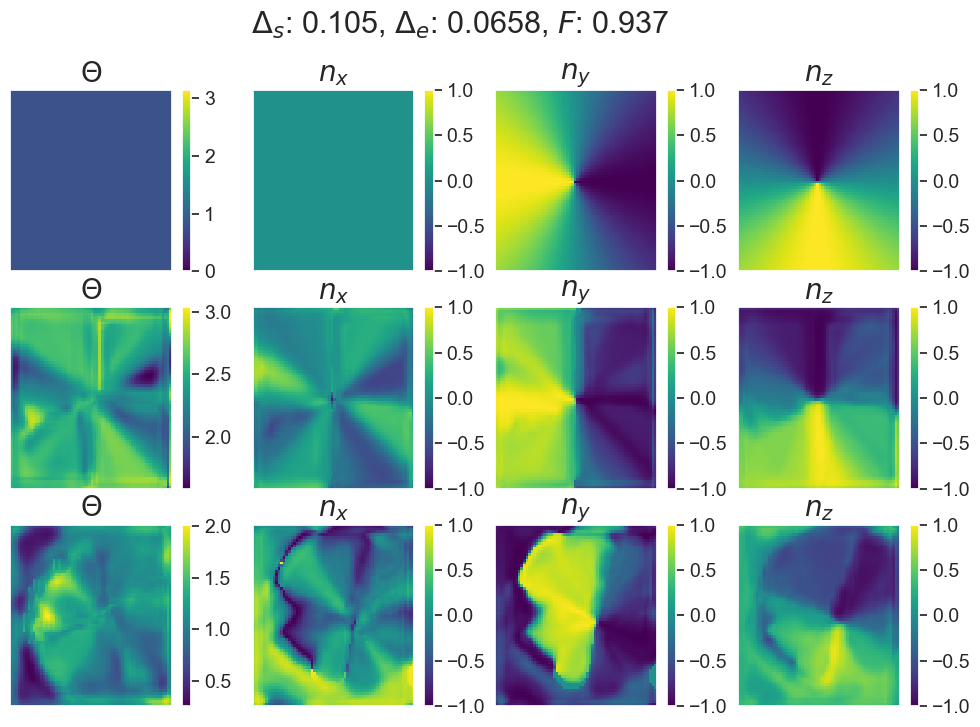

In [263]:
import seaborn as sns

fig,ax = plt.subplots(3, 4, figsize=(12,8))

# Theoretical  

En_th_plot=ax[0,0].pcolormesh(En_th_mat, vmin=0, vmax=np.pi, cmap="viridis")
ax[0,0].get_xaxis().set_visible(False)
ax[0,0].get_yaxis().set_visible(False)
ax[0,0].set_title(r'$\Theta$', fontsize=20)
cbar=fig.colorbar(En_th_plot, ax=ax[0,0])
cbar.ax.tick_params(labelsize=14)

nx_th_plot= ax[0,1].pcolormesh(nz_th_mat, vmin=-1, vmax=1, cmap="viridis")
ax[0,1].get_xaxis().set_visible(False)
ax[0,1].get_yaxis().set_visible(False)
ax[0,1].set_title(r'$n_{x}$', fontsize=20)
cbar=fig.colorbar(nx_th_plot, ax=ax[0,1])
cbar.ax.tick_params(labelsize=14)

ny_th_plot= ax[0,2].pcolormesh(ny_th_mat, vmin=-1, vmax=1, cmap="viridis")
ax[0,2].get_xaxis().set_visible(False)
ax[0,2].get_yaxis().set_visible(False)
ax[0,2].set_title(r'$n_{y}$', fontsize=20)
cbar=fig.colorbar(ny_th_plot, ax=ax[0,2])
cbar.ax.tick_params(labelsize=14)

nz_th_plot= ax[0,3].pcolormesh(nx_th_mat, vmin=-1, vmax=1, cmap="viridis")
ax[0,3].get_xaxis().set_visible(False)
ax[0,3].get_yaxis().set_visible(False)
ax[0,3].set_title(r'$n_{z}$', fontsize=20)
cbar=fig.colorbar(nz_th_plot, ax=ax[0,3])
cbar.ax.tick_params(labelsize=14)

# Theoretical predictions ...

En_synth_plot = ax[1,0].pcolormesh(En_synth_pred, cmap="viridis")
ax[1,0].get_xaxis().set_visible(False)
ax[1,0].get_yaxis().set_visible(False)
ax[1,0].set_title(r'$\Theta$', fontsize=20)
cbar=fig.colorbar(En_synth_plot, ax=ax[1,0])
cbar.ax.tick_params(labelsize=14)

nx_synth_plot = ax[1,1].pcolormesh(nx_synth_pred, vmin=-1, vmax=1, cmap="viridis")
ax[1,1].get_xaxis().set_visible(False)
ax[1,1].get_yaxis().set_visible(False)
ax[1,1].set_title(r'$n_{x}$', fontsize=20)
cbar=fig.colorbar(nx_synth_plot, ax=ax[1,1])
cbar.ax.tick_params(labelsize=14)

ny_synth_plot = ax[1,2].pcolormesh(ny_synth_pred, vmin=-1, vmax=1, cmap="viridis")
ax[1,2].get_xaxis().set_visible(False)
ax[1,2].get_yaxis().set_visible(False)
ax[1,2].set_title(r'$n_{y}$', fontsize=20)
cbar=fig.colorbar(ny_synth_plot, ax=ax[1,2])
cbar.ax.tick_params(labelsize=14)

nz_synth_plot = ax[1,3].pcolormesh(nz_synth_pred, vmin=-1, vmax=1, cmap="viridis")
ax[1,3].get_xaxis().set_visible(False)
ax[1,3].get_yaxis().set_visible(False)
ax[1,3].set_title(r'$n_{z}$', fontsize=20)
cbar=fig.colorbar(nz_synth_plot, ax=ax[1,3])
cbar.ax.tick_params(labelsize=14)

# Experimentals predictions ...

En_exp_plot = ax[2,0].pcolormesh(En_exp_pred, cmap="viridis")
ax[2,0].get_xaxis().set_visible(False)
ax[2,0].get_yaxis().set_visible(False)
ax[2,0].set_title(r'$\Theta$', fontsize=20)
cbar=fig.colorbar(En_exp_plot, ax=ax[2,0])
cbar.ax.tick_params(labelsize=14)

nx_exp_plot= ax[2,1].pcolormesh(nx_exp_pred[::-1], vmin=-1, vmax=1, cmap="viridis")
ax[2,1].get_xaxis().set_visible(False)
ax[2,1].get_yaxis().set_visible(False)
ax[2,1].set_title(r'$n_{x}$', fontsize=20)
cbar=fig.colorbar(nx_exp_plot, ax=ax[2,1])
cbar.ax.tick_params(labelsize=14)


ny_exp_plot = ax[2,2].pcolormesh(-ny_exp_pred[::-1], vmin=-1, vmax=1, cmap="viridis")
ax[2,2].get_xaxis().set_visible(False)
ax[2,2].get_yaxis().set_visible(False)
ax[2,2].set_title(r'$n_{y}$', fontsize=20)
cbar=fig.colorbar(ny_exp_plot, ax=ax[2,2])
cbar.ax.tick_params(labelsize=14)


nz_exp_plot = ax[2,3].pcolormesh(nz_exp_pred[::-1], vmin=-1, vmax=1, cmap="viridis")
ax[2,3].get_xaxis().set_visible(False)
ax[2,3].get_yaxis().set_visible(False)
ax[2,3].set_title(r'$n_{z}$', fontsize=20)
cbar=fig.colorbar(nz_exp_plot, ax=ax[2,3])
cbar.ax.tick_params(labelsize=14)


plt.suptitle(f'$\Delta_s$: {round(synth_pol_delta,4)}, $\Delta_e$: {round(exp_pol_delta,4)}, $F$: {round(avg_fid,4)}', fontsize='22')

sns.set()

# Save the complete reconstruction image 

plt.savefig('reconstructions' + process + f'_{isReord}meas.png', format='png', bbox_inches='tight')

# Appendix: Mess Hall

Plot the direct predictions of the synthetic measurements

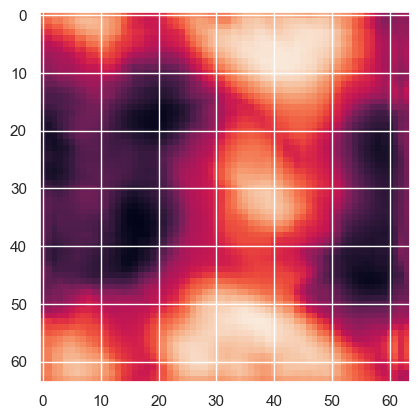

In [225]:
plt.imshow(synth_pred[0,:,:,0])

Save expt reconstruction as txt files

In [246]:

np.savetxt("En_expt_pred.txt", En_exp_pred, delimiter=",")
np.savetxt("nx_expt_pred.txt", nx_exp_pred, delimiter=",")
np.savetxt("ny_expt_pred.txt", ny_exp_pred, delimiter=",")
np.savetxt("nz_expt_pred.txt", nz_exp_pred, delimiter=",")